In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
data = pd.read_csv('new_file.csv')
data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0


In [46]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5535324 entries, 0 to 5535323
Data columns (total 10 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         float64
dtypes: float64(6), int64(1), object(3)
memory usage: 422.3+ MB


In [47]:
data.describe()


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
count,5.535324e+06,5.535324e+06,5.535324e+06,5.535324e+06,5.535324e+06,5.535324e+06,5.535323e+06
mean,2.086180e+02,1.809315e+05,8.411030e+05,8.630069e+05,1.085131e+06,1.213581e+06,7.661703e-04
std,1.117289e+02,6.274806e+05,2.919066e+06,2.955925e+06,3.274792e+06,3.588660e+06,2.766918e-02
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.380000e+02,1.332622e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.130000e+02,7.533635e+04,1.388100e+04,0.000000e+00,1.358954e+05,2.185838e+05,0.000000e+00
75%,3.030000e+02,2.092662e+05,1.073250e+05,1.447372e+05,9.463630e+05,1.118053e+06,0.000000e+00
max,3.810000e+02,9.244552e+07,4.381886e+07,4.368662e+07,3.555534e+08,3.560159e+08,1.000000e+00


In [48]:
obj = (data.dtypes == 'object')
object_cols = list(obj[obj].index)
print("Categorical variables:", len(object_cols))


Categorical variables: 3


In [49]:
int_ = (data.dtypes == 'int')
num_cols = list(int_[int_].index)
print("Integer variables:", len(num_cols))

Integer variables: 1


In [50]:
fl = (data.dtypes == 'float')
fl_cols = list(fl[fl].index)
print("Float variables:", len(fl_cols))

Float variables: 6


<Axes: xlabel='type', ylabel='count'>

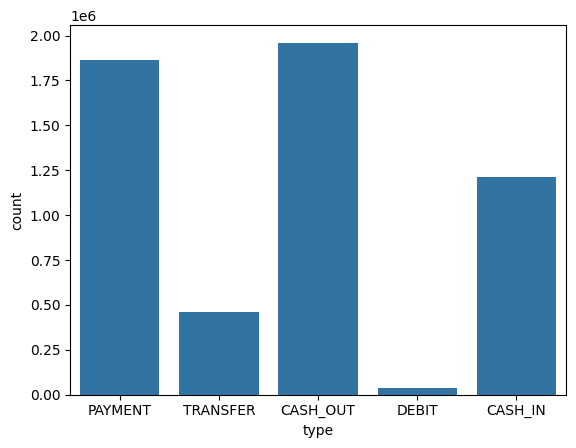

In [51]:
sns.countplot(x='type', data=data)


<Axes: xlabel='type', ylabel='amount'>

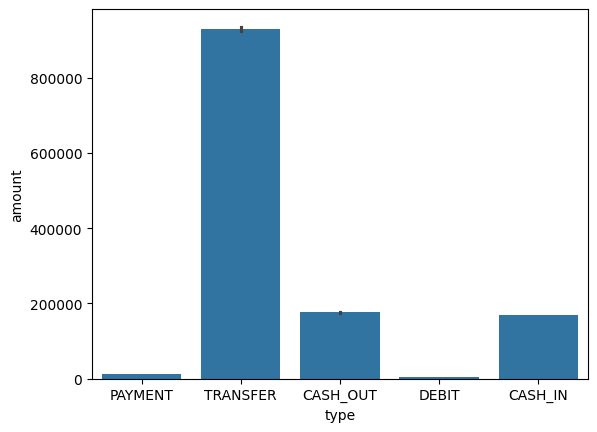

In [52]:
sns.barplot(x='type', y='amount', data=data)


In [53]:
data['isFraud'].value_counts()


,count
isFraud,
0.0,5531082
1.0,4241


/tmp/ipykernel_1906/2319969707.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['step'], bins=50)


<Axes: xlabel='step', ylabel='Density'>

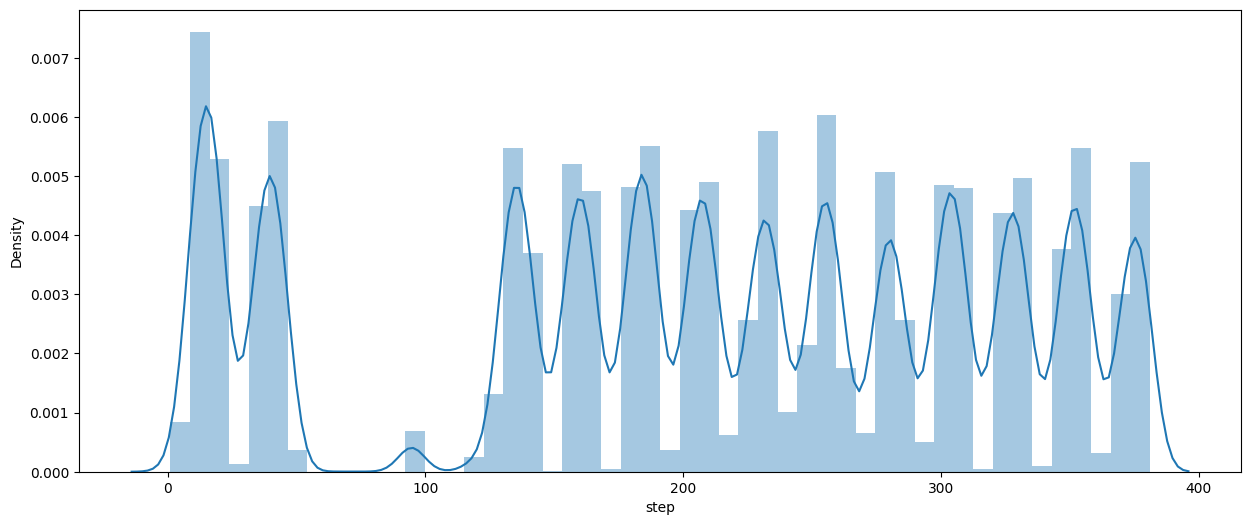

In [54]:
plt.figure(figsize=(15, 6))
sns.distplot(data['step'], bins=50)


<Axes: >

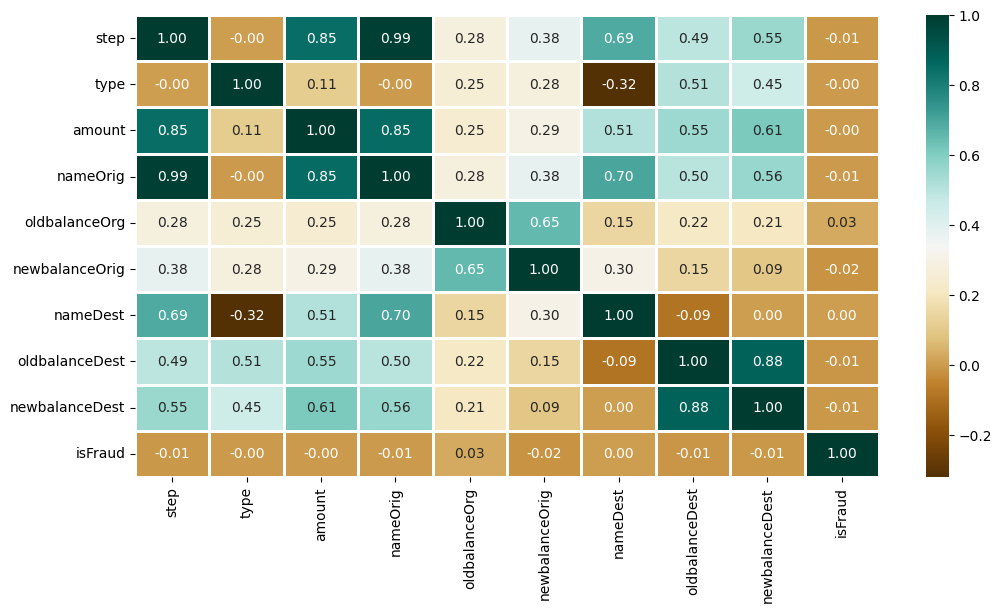

In [55]:
plt.figure(figsize=(12, 6))
sns.heatmap(data.apply(lambda x: pd.factorize(x)[0]).corr(),
			cmap='BrBG',
			fmt='.2f',
			linewidths=2,
			annot=True)


In [56]:
type_new = pd.get_dummies(data['type'], drop_first=True)
data_new = pd.concat([data, type_new], axis=1)
data_new.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,CASH_OUT,DEBIT,PAYMENT,TRANSFER
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,False,False,True,False
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,False,False,True,False
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,False,False,False,True
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,True,False,False,False
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,False,False,True,False


In [57]:
data_new = data_new.dropna(subset=['isFraud'])
X = data_new.drop(['isFraud', 'type', 'nameOrig', 'nameDest'], axis=1)
y = data_new['isFraud']


In [58]:
X.shape, y.shape


((5535323, 10), (5535323,))

In [59]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
	X, y, test_size=0.3, random_state=42)


In [60]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score as ras
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC


In [61]:
models = [LogisticRegression(), XGBClassifier(),
          RandomForestClassifier(n_estimators=7,
                                 criterion='entropy',
                                 random_state=7)]

for i in range(len(models)):
    models[i].fit(X_train, y_train)
    print(f'{models[i]} : ')

    train_preds = models[i].predict_proba(X_train)[:, 1]
    print('Training Accuracy : ', ras(y_train, train_preds))

    y_preds = models[i].predict_proba(X_test)[:, 1]
    print('Validation Accuracy : ', ras(y_test, y_preds))
    print()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression() : 
Training Accuracy :  0.9540339787761754
Validation Accuracy :  0.9493889544885601

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...) : 
Training Accuracy :  0.9860670021713747
Validation Accuracy :  0.9820071295154135

RandomForestClassifier(criterion='entropy', n_

XGB Classifier is best performed model.

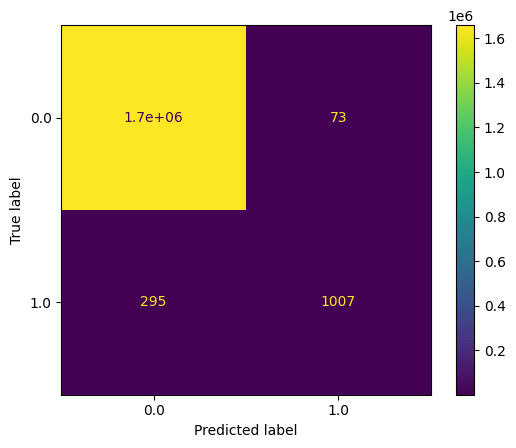

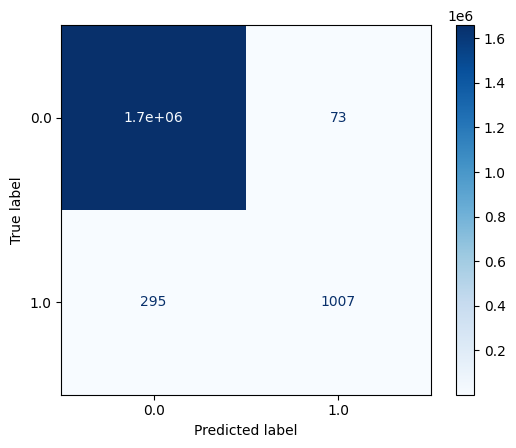

In [62]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = ConfusionMatrixDisplay.from_estimator(models[1], X_test, y_test)

cm.plot(cmap='Blues')

plt.show()

In [64]:

best_model = models[1]


test_probs = best_model.predict_proba(X_test)[:, 1]
test_roc_auc = ras(y_test, test_probs)


y_pred_hard = (test_probs >= 0.5).astype(int)
y_true = y_test.to_numpy()


tp = np.sum((y_true == 1) & (y_pred_hard == 1))
tn = np.sum((y_true == 0) & (y_pred_hard == 0))
fp = np.sum((y_true == 0) & (y_pred_hard == 1))
fn = np.sum((y_true == 1) & (y_pred_hard == 0))


accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0


print(f"ROC-AUC Score :  {test_roc_auc:.4f}")
print(f"Accuracy      :  {accuracy:.4f}")
print(f"Precision     :  {precision:.4f}  (Reliability of fraud alerts)")
print(f"Recall        :  {recall:.4f}  (% of actual fraud caught)")
print(f"F1-Score      :  {f1_score:.4f}")


ROC-AUC Score :  0.9820
Accuracy      :  0.9998
Precision     :  0.9324  (Reliability of fraud alerts)
Recall        :  0.7734  (% of actual fraud caught)
F1-Score      :  0.8455
